# First Name : Elijah
# Last Name : Ang

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
nesarc = pd.read_csv('nesarc.csv', low_memory=False)
pd.set_option('display.float_format', lambda x:'%f'%x)

# From Prac 1
# Columns/Data used in Prac 1

In [3]:
nesarc['S2AQ5B'] = pd.to_numeric(nesarc['S2AQ5B'], errors='coerce') #convert variable to numeric
nesarc['S2AQ5D'] = pd.to_numeric(nesarc['S2AQ5D'], errors='coerce') #convert variable to numeric
nesarc['S2AQ5A'] = pd.to_numeric(nesarc['S2AQ5A'], errors='coerce') #convert variable to numeric
nesarc['S2BQ1B1'] = pd.to_numeric(nesarc['S2BQ1B1'], errors='coerce') #convert variable to numeric
nesarc['AGE'] = pd.to_numeric(nesarc['AGE'], errors='coerce') #convert variable to numeric

# From Prac 2
# A subset of nesarc data, with the following criteria
# Age from 26 to 50
# Beer drinking status - S2AQ5A = Y

In [4]:
sub1=nesarc[(nesarc['AGE']>=26) & (nesarc['AGE']<=50) & (nesarc['S2AQ5A']==1)]
sub2=sub1.copy()

# From Prac 2
# SETTING MISSING DATA

In [5]:
sub2['S2AQ5D']=sub2['S2AQ5D'].replace(99, np.nan)

sub2['S2AQ5B']=sub2['S2AQ5B'].replace(8, np.nan)
sub2['S2AQ5B']=sub2['S2AQ5B'].replace(9, np.nan)
sub2['S2AQ5B']=sub2['S2AQ5B'].replace(10, np.nan)
sub2['S2AQ5B']=sub2['S2AQ5B'].replace(99, np.nan)

sub2['S2BQ1B1']=sub2['S2BQ1B1'].replace(9, np.nan)

# From Prac 2
# Recode data

In [6]:
recode2 = {1:30, 2:26, 3:14, 4:8, 5:4, 6:2.5, 7:1}
sub2['BEER_FEQMO']= sub2['S2AQ5B'].map(recode2)

recode3 = {2:0, 1:1}
sub2['S2BQ1B1']= sub2['S2BQ1B1'].map(recode3)

# From Prac 2
# Create secondary variables

In [7]:
# A secondary variable multiplying the number of days beer consumed/month and the approx number of 
# beer consumed/day
sub2['NUMBEERMO_EST']=sub2['BEER_FEQMO'] * sub2['S2AQ5D']

# Draw a Line chart
# Age vs Number of beer consumed per month (NUMBEERMO_EST)

# a) mean number of beer consumed
# var = mean number of beers consumed a month, grouped by age

In [8]:
var = sub2.groupby('AGE')['NUMBEERMO_EST'].mean()
print(var)

AGE
26   23.701357
27   23.854545
28   30.035270
29   23.994949
30   24.170530
31   25.541033
32   25.678994
33   24.761017
34   23.143713
35   28.668478
36   26.813272
37   28.530387
38   26.414773
39   27.307122
40   31.571023
41   23.233788
42   31.877676
43   28.045455
44   37.279762
45   27.067241
46   31.727799
47   33.204918
48   33.655303
49   28.177778
50   28.995614
Name: NUMBEERMO_EST, dtype: float64


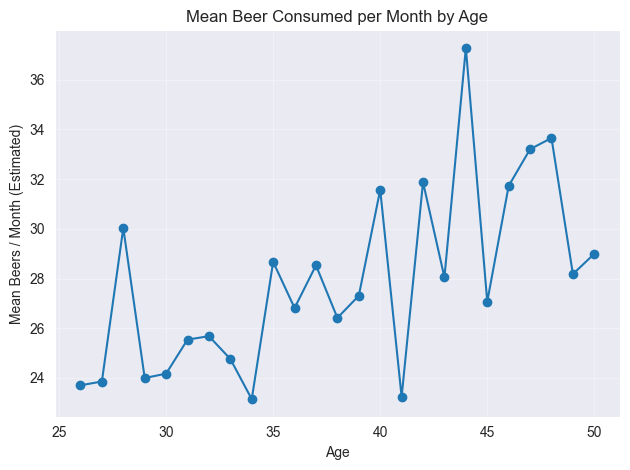

In [9]:
fig = plt.figure()
plt.plot(var.index, var.values, marker='o')
plt.xlabel('Age')
plt.ylabel('Mean Beers / Month (Estimated)')
plt.title('Mean Beer Consumed per Month by Age')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# b) total number of beer consumed
# var2 = sum number of beers consumed a month, grouped by age

In [10]:
var2 = sub2.groupby('AGE')['NUMBEERMO_EST'].sum()
print(var2)

AGE
26    5238.000000
27    6560.000000
28    7238.500000
29    7126.500000
30    7299.500000
31    8403.000000
32    8679.500000
33    7304.500000
34    7730.000000
35    7912.500000
36    8687.500000
37   10328.000000
38    9298.000000
39    9202.500000
40   11113.000000
41    6807.500000
42   10424.000000
43    8021.000000
44    9394.500000
45    7849.500000
46    8217.500000
47    8102.000000
48    8885.000000
49    6340.000000
50    6611.000000
Name: NUMBEERMO_EST, dtype: float64


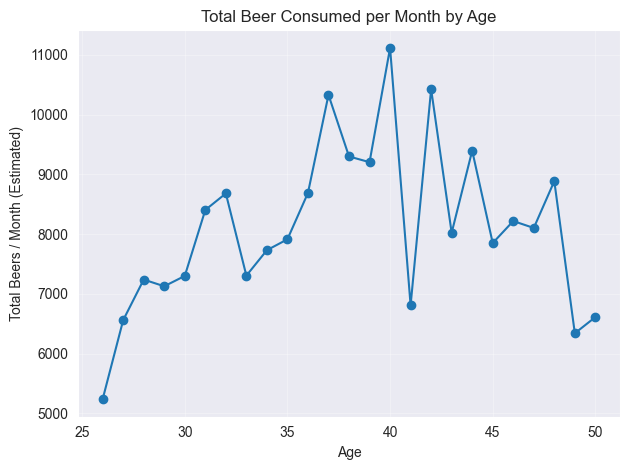

In [11]:
fig = plt.figure()
plt.plot(var2.index, var2.values, marker='o')
plt.xlabel('Age')
plt.ylabel('Total Beers / Month (Estimated)')
plt.title('Total Beer Consumed per Month by Age')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Draw a stacked Column Chart
# x = age (AGE)
# y = number of beers consumed per month (NUMBEERMO_EST)
# stack is based on depedency on beer (S2BQ1B1)

# var3 = mean number of beers consumed a month, grouped by age and beer depedency (S2BQ1B1)

In [12]:
var3 = sub2.groupby(['AGE', 'S2BQ1B1'])['NUMBEERMO_EST'].mean().unstack()
print(var3)

S2BQ1B1  0.000000   1.000000
AGE                         
26      21.449239  49.947368
27      23.809524  24.347826
28      26.021127  67.460000
29      20.869650  44.078947
30      21.530797  54.086957
31      23.482026  55.113636
32      23.871753  47.722222
33      23.255556  45.075000
34      21.732899  47.250000
35      28.266537  32.375000
36      24.372881  56.800000
37      23.248503 101.240000
38      24.274390  61.619048
39      26.789308  41.718750
40      30.580793  46.477273
41      21.989091  44.441176
42      30.563725  58.029412
43      26.249071  49.642857
44      34.893665  49.416667
45      25.614232  48.083333
46      30.041841  51.416667
47      27.116438  97.450000
48      27.997992 127.566667
49      27.356132  44.636364
50      25.077465 102.541667


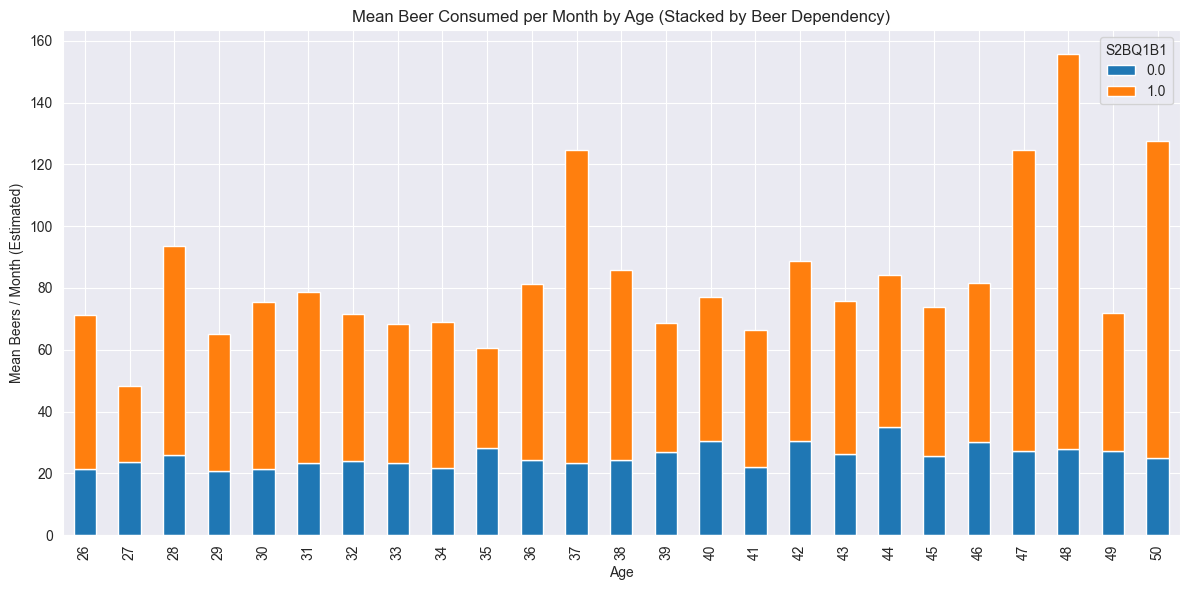

In [13]:
ax = var3.plot(kind='bar', stacked=True, figsize=(12, 6))
ax.set_xlabel('Age')
ax.set_ylabel('Mean Beers / Month (Estimated)')
ax.set_title('Mean Beer Consumed per Month by Age (Stacked by Beer Dependency)')
plt.tight_layout()
plt.show()

# Draw a horizontal stacked Column Chart
# x = age (AGE)
# y = number of beers consumed per month (NUMBEERMO_EST)
# stack is based on depedency on  beer (S2BQ1B1)

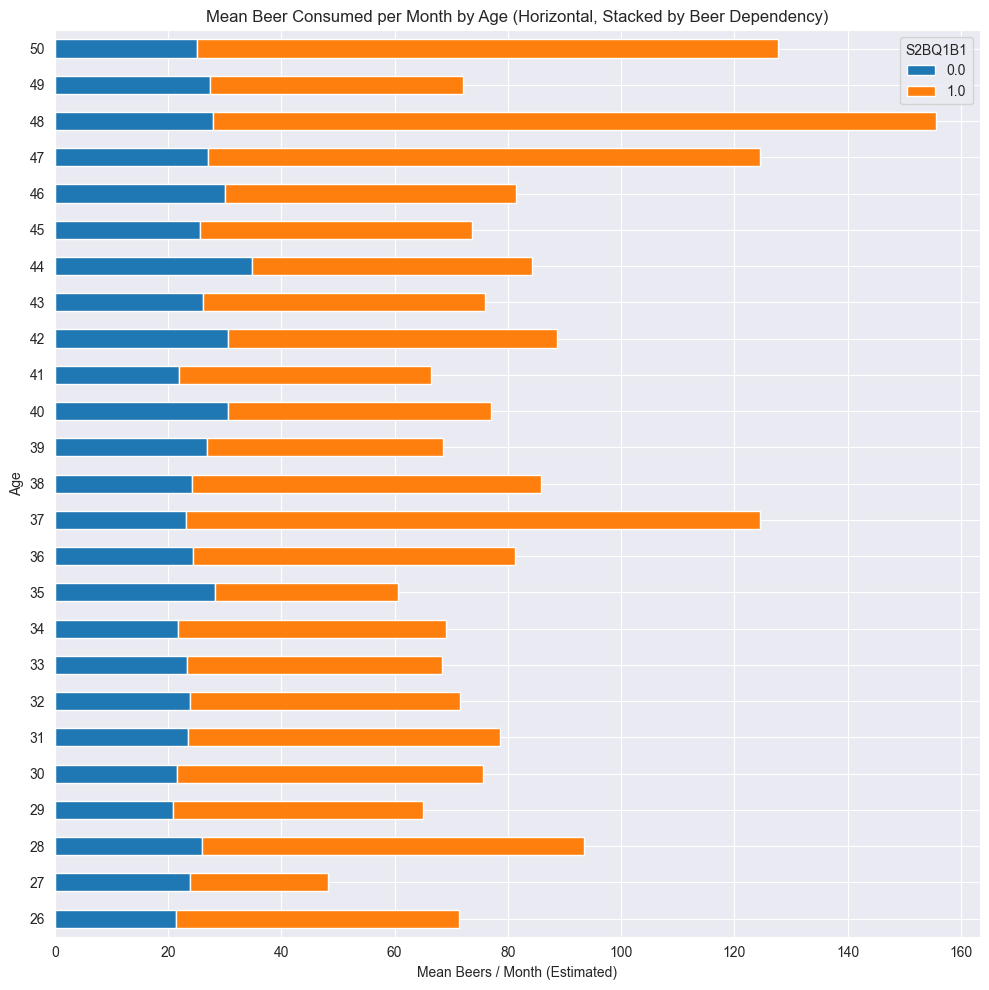

In [14]:
ax = var3.plot(kind='barh', stacked=True, figsize=(10, 10))
ax.set_xlabel('Mean Beers / Month (Estimated)')
ax.set_ylabel('Age')
ax.set_title('Mean Beer Consumed per Month by Age (Horizontal, Stacked by Beer Dependency)')
plt.tight_layout()
plt.show()

# Draw a Pie Chart showing age (AGE) and total beer consumed a month (NUMBEERMO_EST)
# hint use var2

In [15]:
print(var2)

AGE
26    5238.000000
27    6560.000000
28    7238.500000
29    7126.500000
30    7299.500000
31    8403.000000
32    8679.500000
33    7304.500000
34    7730.000000
35    7912.500000
36    8687.500000
37   10328.000000
38    9298.000000
39    9202.500000
40   11113.000000
41    6807.500000
42   10424.000000
43    8021.000000
44    9394.500000
45    7849.500000
46    8217.500000
47    8102.000000
48    8885.000000
49    6340.000000
50    6611.000000
Name: NUMBEERMO_EST, dtype: float64


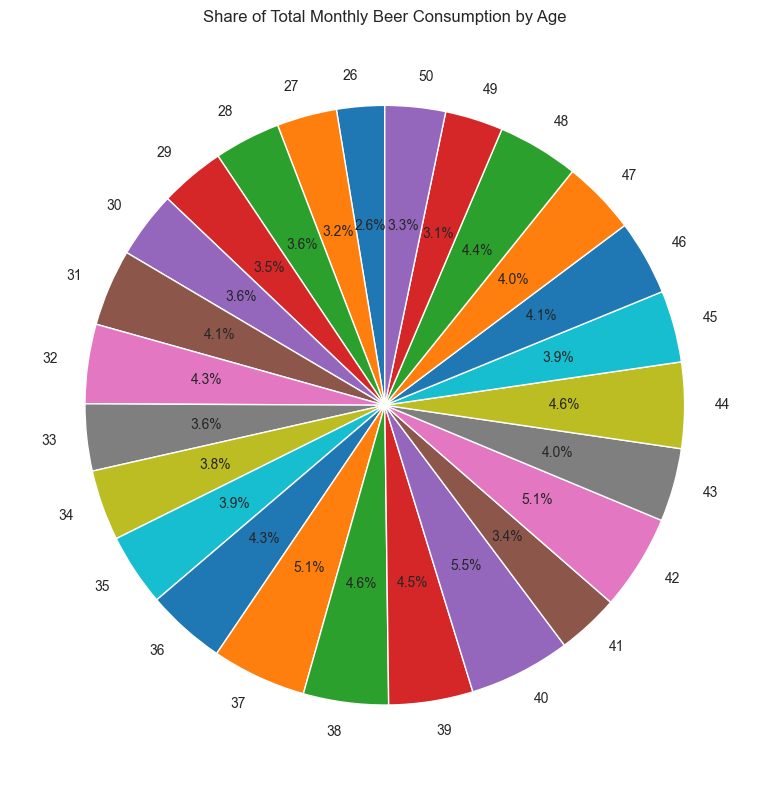

In [16]:
fig = plt.figure(figsize=(10, 8))
plt.pie(var2.values, labels=var2.index, autopct='%1.1f%%', startangle=90)
plt.title('Share of Total Monthly Beer Consumption by Age')
plt.tight_layout()
plt.show()

# Draw a Violin Plot for age (AGE) and income (S1Q10A)

# convert income (S1Q10A) to numeric

In [17]:
sub2['S1Q10A'] = pd.to_numeric(sub2['S1Q10A']) #convert variable to numeric

# Plot violin plot

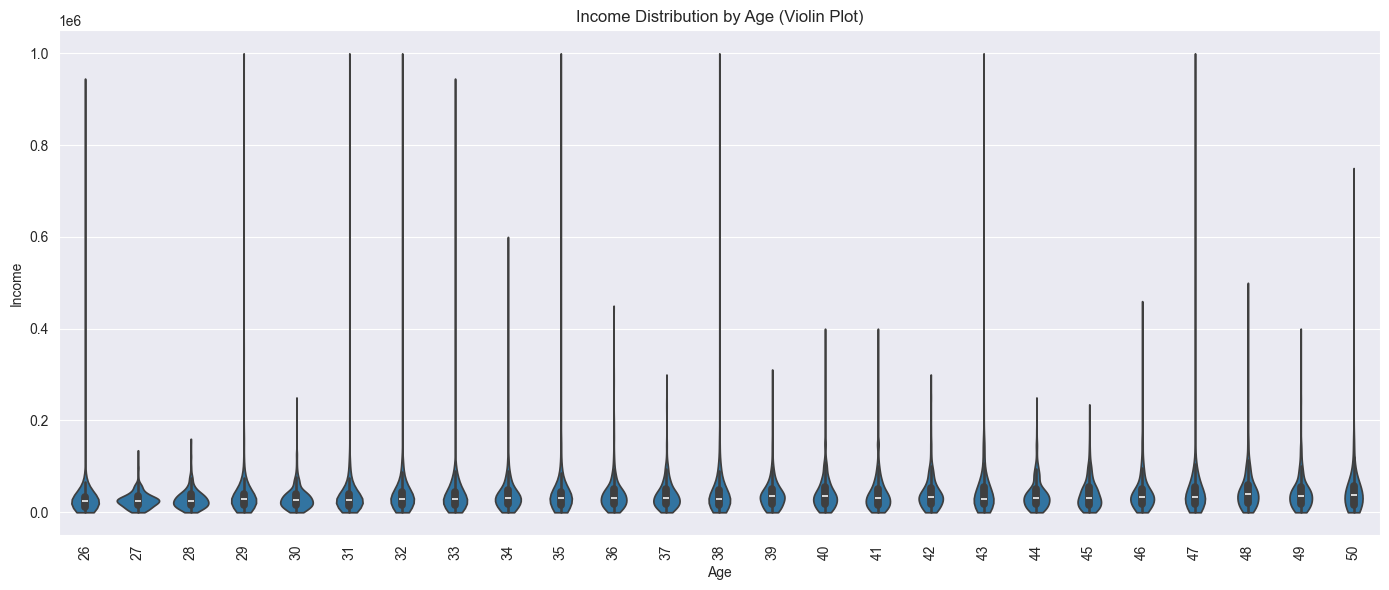

In [18]:
fig = plt.figure(figsize=(14, 6))
sns.violinplot(x='AGE', y='S1Q10A', data=sub2, cut=0)
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income Distribution by Age (Violin Plot)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Draw a HeatMap for Ethnicity and Carton of Beer consumed per month, based on depedency on beer

# Rename Race - From Module 4

In [19]:
# you can rename categorical variable values for graphing if original values are not informative 
# first change the variable format to categorical if you haven’t already done so
sub2['ETHRACE2A'] = sub2['ETHRACE2A'].astype('category')

sub2['ETHRACE2A']=sub2['ETHRACE2A'].cat.rename_categories(["White", "Black", "NatAm", "Asian", "Hispanic"])

# Create a new variable DRINK_ADAY using DRINK_ADAY function provided

In [21]:
def DRINK_ADAY (row):
   if row['BEER_FEQMO'] >= 30 :
      return 1
   elif row['BEER_FEQMO'] < 30 :
      return 0
    
sub2['DRINK_ADAY'] = sub2.apply(DRINK_ADAY, axis=1)

# Print the size of DRINK_ADAY, grouped by category

In [22]:
c4= sub2.groupby('DRINK_ADAY').size()
print(c4)

DRINK_ADAY
0.000000    6897
1.000000     417
dtype: int64


# Draw bar chart to show relationship between race (ETHRACE2A) and DRINK_ADAY

In [23]:
%matplotlib notebook

fig = plt.figure(figsize=(8, 5))
sns.barplot(x='ETHRACE2A', y='DRINK_ADAY', data=sub2, ci=None)
plt.xlabel('Ethnic Group')
plt.ylabel('Proportion of Daily Beer Drinkers')
plt.title('Proportion of Daily Beer Drinkers by Ethnic Group')
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>

/var/folders/m_/5hjxnlm94j53h6kj050rk1300000gn/T/ipykernel_15785/1339846453.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='ETHRACE2A', y='DRINK_ADAY', data=sub2, ci=None)


# Make copy of just race (ETHRACE2A) and DRINK_ADAY

In [24]:
sub3 = sub2[['ETHRACE2A','DRINK_ADAY']].copy()
sub3.head()

,ETHRACE2A,DRINK_ADAY
1,Hispanic,NaN
8,White,NaN
12,Asian,0.000000
16,White,NaN
24,Hispanic,NaN


# Create pivot table of race (ETHRACE2A) and DRINK_ADAY

In [25]:
table = pd.crosstab(sub3['ETHRACE2A'], sub3['DRINK_ADAY'], normalize='index')
print(table)

DRINK_ADAY  0.000000  1.000000
ETHRACE2A                     
White       0.947993  0.052007
Black       0.893926  0.106074
NatAm       0.940678  0.059322
Asian       0.958974  0.041026
Hispanic    0.962351  0.037649


# Draw heat map

In [26]:
fig = plt.figure(figsize=(7, 5))
sns.heatmap(table, annot=True, fmt='.2f')
plt.xlabel('DRINK_ADAY (0 = Not Daily, 1 = Daily)')
plt.ylabel('Ethnic Group')
plt.title('Proportion of Daily Beer Drinkers by Ethnic Group')
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>

# Draw a bubble Chart

# Read in gapminder.csv

In [28]:
pd.set_option('display.float_format', lambda x:'%.2f'%x)

gapminder = pd.read_csv('gapminder.csv', low_memory=False)
gapminder.head()

,country,incomeperperson,alcconsumption,armedforcesrate,breastcancerper100th,co2emissions,femaleemployrate,hivrate,internetuserate,lifeexpectancy,oilperperson,polityscore,relectricperperson,suicideper100th,employrate,urbanrate
0,Afghanistan,,.03,.5696534,26.8,75944000,25.6000003814697,,3.65412162280064,48.673,,0,,6.68438529968262,55.7000007629394,24.04
1,Albania,1914.99655094922,7.29,1.0247361,57.4,223747333.333333,42.0999984741211,,44.9899469578783,76.918,,9,636.341383366604,7.69932985305786,51.4000015258789,46.72
2,Algeria,2231.99333515006,.69,2.306817,23.5,2932108666.66667,31.7000007629394,.1,12.5000733055148,73.131,.42009452521537,2,590.509814347428,4.8487696647644,50.5,65.22
3,Andorra,21943.3398976022,10.17,,,,,,81,,,,,5.36217880249023,,88.92
4,Angola,1381.00426770244,5.57,1.4613288,23.1,248358000,69.4000015258789,2,9.99995388324075,51.093,,-2,172.999227388199,14.5546770095825,75.6999969482422,56.7


# Convert internetuserate, urbanrate and incomeperperson to numeric 

In [29]:
gapminder['internetuserate'] = pd.to_numeric(gapminder['internetuserate'], errors='coerce')
gapminder['urbanrate'] = pd.to_numeric(gapminder['urbanrate'], errors='coerce')
gapminder['incomeperperson'] = pd.to_numeric(gapminder['incomeperperson'], errors='coerce')

In [30]:
gapminder_clean=gapminder.dropna()

# Draw a bubble Chart
# x = urbanrate
# y = income per person
# bubble size = internetuserate

In [31]:
%matplotlib notebook
fig = plt.figure(figsize=(8, 6))

plt.scatter(
    gapminder_clean['urbanrate'],
    gapminder_clean['incomeperperson'],
    s=gapminder_clean['internetuserate'] * 5,
    alpha=0.5
)

plt.xlabel('Urban Rate')
plt.ylabel('Income Per Person')
plt.title('Income vs Urban Rate (Bubble size = Internet Use Rate)')
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>